In [1]:
import pandas as pd

In [5]:
fx = pd.read_csv('data_safe_copy.csv', index_col=0)
fx.index = sorted(fx.index)

In [6]:
fx.head()

,EURUSD,GBPUSD,PLNUSD,USDPLN,USDJPY,AUDUSD,NZDUSD,USDCAD,USDCHF,EURPLN,GBPPLN
2025-01-02,1.02661,1.23826,0.240270,4.16199,157.4610,0.62033,0.55966,1.44067,0.91210,4.27274,5.15363
2025-01-03,1.03062,1.24267,0.241453,4.14160,157.3420,0.62176,0.56089,1.44467,0.90891,4.26841,5.14664
2025-01-06,1.03900,1.25188,0.244290,4.09350,157.6200,0.62427,0.56402,1.43330,0.90478,4.25315,5.12457
2025-01-07,1.03426,1.24771,0.242804,4.11855,158.0405,0.62326,0.56331,1.43683,0.90937,4.25965,5.13875
2025-01-08,1.03185,1.23638,0.241377,4.14290,158.3085,0.62132,0.56058,1.43758,0.91101,4.27485,5.12220


In [7]:
fx.tail()

,EURUSD,GBPUSD,PLNUSD,USDPLN,USDJPY,AUDUSD,NZDUSD,USDCAD,USDCHF,EURPLN,GBPPLN
2026-01-26,1.18777,1.36768,0.282362,3.54155,154.1550,0.69100,0.59697,1.37115,0.77720,4.20655,4.84370
2026-01-27,1.20426,1.38461,0.286789,3.48689,152.3020,0.70092,0.60433,1.35758,0.76114,4.19912,4.82798
2026-01-28,1.19562,1.38024,0.284316,3.51721,153.4235,0.70384,0.60594,1.35621,0.76859,4.20524,4.85459
2026-01-29,1.19695,1.38095,0.284600,3.51370,153.0050,0.70497,0.60751,1.34872,0.76476,4.20572,4.85224
2026-01-30,1.18534,1.36839,0.281465,3.55284,154.7785,0.69637,0.60212,1.36162,0.77302,4.21132,4.86167


<Axes: title={'center': 'EURUSD exchange rate'}, xlabel='Date', ylabel='Price'>

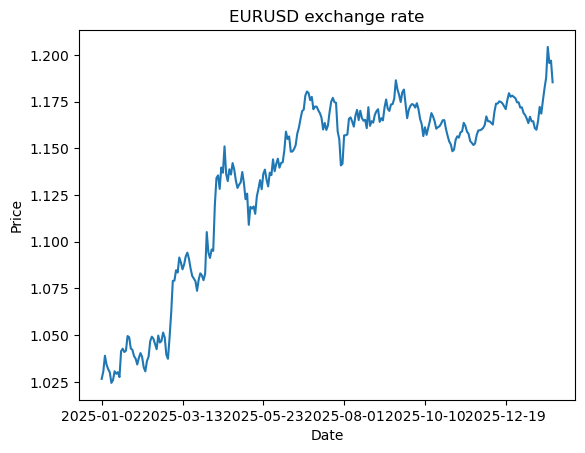

In [11]:
fx['EURUSD'].plot(xlabel='Date', ylabel='Price', title='EURUSD exchange rate')

<Axes: title={'center': 'USDPLN exchange rate'}, xlabel='Date', ylabel='Price'>

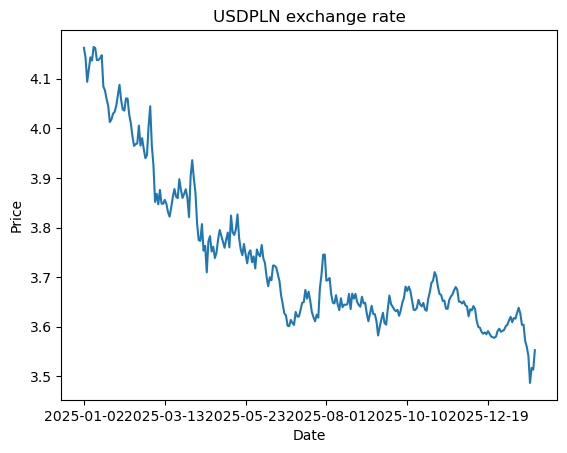

In [12]:
fx['USDPLN'].plot(xlabel='Date', ylabel='Price', title='USDPLN exchange rate')

<Axes: title={'center': 'USDPLN and EURUSD exchange rates'}, xlabel='Date', ylabel='Price'>

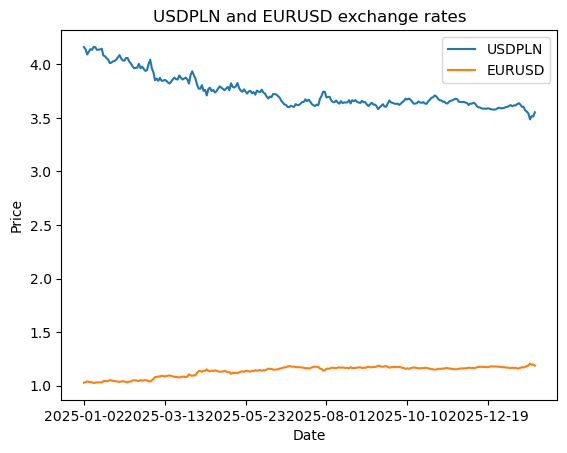

In [13]:
fx[['USDPLN', 'EURUSD']].plot(xlabel='Date', ylabel='Price', title='USDPLN and EURUSD exchange rates')

In [20]:
rolling_mean_usdpln = fx['USDPLN'].rolling(window=7).mean()
rolling_mean_eurusd = fx['EURUSD'].rolling(window=7).mean()
rolling_std_usdpln = fx['USDPLN'].rolling(window=7).std()
rolling_std_eurusd = fx['EURUSD'].rolling(window=7).std()

print("Rolling mean USDPLN:\n", rolling_mean_usdpln.head(10))
print("Rolling mean EURUSD:\n", rolling_mean_eurusd.head(10))
print("Rolling std USDPLN:\n", rolling_std_usdpln.head(10))
print("Rolling std EURUSD:\n", rolling_std_eurusd.head(10))
print("NaN count in rolling mean USDPLN:", rolling_mean_usdpln.isna().sum())
print("NaN count in rolling mean EURUSD:", rolling_mean_eurusd.isna().sum())
print("NaN count in rolling std USDPLN:", rolling_std_usdpln.isna().sum())
print("NaN count in rolling std EURUSD:", rolling_std_eurusd.isna().sum())

Rolling mean USDPLN:
 2025-01-02         NaN
2025-01-03         NaN
2025-01-06         NaN
2025-01-07         NaN
2025-01-08         NaN
2025-01-09         NaN
2025-01-10    4.136947
2025-01-13    4.136877
2025-01-14    4.136270
2025-01-15    4.142570
Name: USDPLN, dtype: float64
Rolling mean EURUSD:
 2025-01-02         NaN
2025-01-03         NaN
2025-01-06         NaN
2025-01-07         NaN
2025-01-08         NaN
2025-01-09         NaN
2025-01-10    1.030991
2025-01-13    1.030900
2025-01-14    1.030911
2025-01-15    1.029531
Name: EURUSD, dtype: float64
Rolling std USDPLN:
 2025-01-02         NaN
2025-01-03         NaN
2025-01-06         NaN
2025-01-07         NaN
2025-01-08         NaN
2025-01-09         NaN
2025-01-10    0.024601
2025-01-13    0.024519
2025-01-14    0.024435
2025-01-15    0.015690
Name: USDPLN, dtype: float64
Rolling std EURUSD:
 2025-01-02         NaN
2025-01-03         NaN
2025-01-06         NaN
2025-01-07         NaN
2025-01-08         NaN
2025-01-09         NaN

In [ ]:
dates = fx.index
prices_usdpln = fx['USDPLN']
fx['baseline_pred'] = fx['USDPLN'].shift(1)
fx['abs_error'] = (fx['USDPLN'] - fx['baseline_pred']).abs()
mae = fx['abs_error'].mean()
print(f"Mean Absolute Error (MAE): {mae:.4f}")
non_missing_count = fx['baseline_pred'].notna().sum()
expected_count = len(fx) - 1

print(f"Non-missing predictions: {non_missing_count}")
print(f"Expected count (Total rows - 1): {expected_count}")

assert non_missing_count == expected_count, "Validation Failed: The count of non-missing predictions does not equal total rows minus one."
print("Validation Check Passed!")

print("\nForecast Data:")
print(fx)

Mean Absolute Error (MAE): 0.0168
Non-missing predictions: 279
Expected count (Total rows - 1): 279
Validation Check Passed!

Forecast Data:
             EURUSD   GBPUSD    PLNUSD   USDPLN    USDJPY   AUDUSD   NZDUSD  \
2025-01-02  1.02661  1.23826  0.240270  4.16199  157.4610  0.62033  0.55966   
2025-01-03  1.03062  1.24267  0.241453  4.14160  157.3420  0.62176  0.56089   
2025-01-06  1.03900  1.25188  0.244290  4.09350  157.6200  0.62427  0.56402   
2025-01-07  1.03426  1.24771  0.242804  4.11855  158.0405  0.62326  0.56331   
2025-01-08  1.03185  1.23638  0.241377  4.14290  158.3085  0.62132  0.56058   
...             ...      ...       ...      ...       ...      ...      ...   
2026-01-26  1.18777  1.36768  0.282362  3.54155  154.1550  0.69100  0.59697   
2026-01-27  1.20426  1.38461  0.286789  3.48689  152.3020  0.70092  0.60433   
2026-01-28  1.19562  1.38024  0.284316  3.51721  153.4235  0.70384  0.60594   
2026-01-29  1.19695  1.38095  0.284600  3.51370  153.0050  0.70497  0

In [24]:
import json

# 1. Your actual script variables (replace these with your real variables)
selected_pairs = ['EUR/USD', 'USD/PLN']
window_size_used = 7
calculated_mae = 0.0168
dataset_start = '2025-01-02'
dataset_end = '2026-01-30'

# 2. Create the report dictionary
report_dict = {
    'currency_pairs': selected_pairs,
    'rolling_window_size': window_size_used,
    'baseline_mae': calculated_mae,
    'date_range': f"{dataset_start} to {dataset_end}"
}

# 3. Print the report
print("--- Forecasting Experiment Report ---")
# Using json.dumps for a nicely indented, easy-to-read output
print(json.dumps(report_dict, indent=4))
print("-------------------------------------\n")

# 4. Explicit validation check
# Confirm the rolling window size in the dictionary matches the actual variable used in your calculations
print("Running validation checks...")

assert report_dict['rolling_window_size'] == window_size_used, \
    f"Mismatch Error: Dictionary specifies {report_dict['rolling_window_size']} but actual used was {window_size_used}."

print("Validation Passed: Rolling window size in the report matches the expected value.")

--- Forecasting Experiment Report ---
{
    "currency_pairs": [
        "EUR/USD",
        "USD/PLN"
    ],
    "rolling_window_size": 7,
    "baseline_mae": 0.0168,
    "date_range": "2025-01-02 to 2026-01-30"
}
-------------------------------------

Running validation checks...
Validation Passed: Rolling window size in the report matches the expected value.
